# Sketch vs Visual Face Similarity
**Goal:** Extract features from sketches and visual images, then compute cosine similarity.
- Same person (sketch ↔ own visual) → similarity should be **HIGH** (distance LOW)
- Different person (sketch A ↔ visual B) → similarity should be **LOW** (distance HIGH)

### Expected folder structure:
```
dataset/
├── person_001/
│   ├── visual/   ← multiple photos
│   └── sketch/   ← one sketch
├── person_002/
│   ├── visual/
│   └── sketch/
...
```

In [1]:
# Cell 1 — Imports
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Model
from keras_vggface.vggface import VGGFace
from keras_vggface.utils import preprocess_input as vggface_preprocess
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import gc

print('TensorFlow:', tf.__version__)
print('NumPy     :', np.__version__)
print('All imports done.')


/Users/pankaj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.13.0
NumPy     : 1.24.3
All imports done.


In [2]:
# Cell 2 — Settings  ← only edit this cell

DATASET_DIR  = '/Users/pankaj/Desktop/sketch_project/LFW_Cropped'   # inner folder containing one subfolder per person
VISUAL_DIR   = 'visual'       # name of visual subfolder inside each person folder
SKETCH_DIR   = 'sketch'       # name of sketch subfolder inside each person folder
LAYER        = 'fc6'          # fc6 or fc7
OUTPUT_DIR   = './features_tantring_with_mild_sharp'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Dataset : {DATASET_DIR}')
print(f'Layer   : {LAYER}')


Dataset : /Users/pankaj/Desktop/sketch_project/LFW_Cropped
Layer   : fc6


In [3]:
# Cell 3 — Load VGGFace model

print('Loading VGGFace...')
base_model = VGGFace(model='vgg16', include_top=True, input_shape=(224, 224, 3))
extractor  = Model(inputs=base_model.input,
                   outputs=base_model.get_layer(LAYER).output)
extractor.trainable = False
print(f'VGGFace loaded  |  output: {extractor.output_shape}')
print('Model ready.')


Loading VGGFace...
VGGFace loaded  |  output: (None, 4096)
Model ready.


In [4]:
# Cell 4 — Preprocessing helpers
# Tan-Triggs normalization is applied to BOTH sketches and photos.
# It removes broad lighting gradients while preserving the mid-frequency
# identity details that VGGFace actually uses for recognition.
# This is critical for sketch-to-photo matching because:
#   - Photos have skin texture, colour, lighting variation
#   - Sketches have none of that — only edges and geometry remain
# Tan-Triggs brings both closer to the same "lighting-neutral" space.

EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

# ── Tan-Triggs Normalization ─────────────────────────────────────────────
# Parameters:
#   gamma=0.8  : mild gamma — barely alters values, keeps inter-person diffs
#   sigma1=32  : large DoG radius → removes only BROAD lighting, not texture
def tan_triggs(img_bgr, gamma=0.8, sigma0=1.0, sigma1=32.0, tau=10.0, alpha=0.1):
    img_f = img_bgr.astype(np.float32) / 255.0
    img_f = np.power(img_f + 1e-6, gamma)
    result = np.zeros_like(img_f)
    for c in range(3):
        g1 = cv2.GaussianBlur(img_f[:, :, c], (0, 0), sigma0)
        g2 = cv2.GaussianBlur(img_f[:, :, c], (0, 0), sigma1)
        result[:, :, c] = g1 - g2
    mean_abs = np.mean(np.abs(result)) + 1e-6
    result = result / mean_abs
    result = tau * np.tanh(result / tau)
    mean_abs2 = (np.mean(np.abs(result) ** alpha)) ** (1.0 / alpha) + 1e-6
    result = result / mean_abs2
    result = result - result.min()
    result = result / (result.max() + 1e-6)
    return (result * 255.0).astype(np.float32)


# ── Sketch-specific enhancement ─────────────────────────────────────────
# After Tan-Triggs, apply mild unsharp mask to crisp up pencil edges.
# Sketches lose edge sharpness during resizing — this restores it.
def enhance_sketch(img_bgr):
    tt      = tan_triggs(img_bgr)
    blurred = cv2.GaussianBlur(tt, (0, 0), 2.0)
    sharp   = cv2.addWeighted(tt, 1.2, blurred, -0.2, 0)
    return np.clip(sharp, 0, 255).astype(np.float32)


def load_image(path, is_sketch=False):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f'Cannot read: {path}')
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img = cv2.resize(img, (224, 224))
    if is_sketch:
        img = enhance_sketch(img)   # Tan-Triggs + edge sharpening
    else:
        img = tan_triggs(img)       # Tan-Triggs only
    return img.astype(np.float32)


# ── VGGFace feature extractors ───────────────────────────────────────────
def extract_features_batch(img_array_batch):
    """
    Batch VGGFace inference.
    Input : (B, 224, 224, 3) float32 BGR numpy array
    Output: (B, 4096) L2-normalised feature vectors
    """
    x     = vggface_preprocess(img_array_batch.copy(), version=1)
    feats = extractor.predict(x, verbose=0)
    return normalize(feats)


print('Helpers ready.')
print('  Preprocessing : Tan-Triggs (gamma=0.8, sigma0=1, sigma1=32)')
print('  Sketch extras : Tan-Triggs + unsharp mask')
print('  VGGFace output: 4096-d L2-normalised vectors')


Helpers ready.
  Preprocessing : Tan-Triggs (gamma=0.8, sigma0=1, sigma1=32)
  Sketch extras : Tan-Triggs + unsharp mask
  VGGFace output: 4096-d L2-normalised vectors


In [5]:
# Cell 5 — Scan dataset and collect all persons
persons = sorted([
    p for p in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, p))
])

print(f'Found {len(persons)} persons:')
for p in persons[:5]:
    print(f'  {p}')
if len(persons) > 5:
    print(f'  ... and {len(persons)-5} more')

Found 2753 persons:
  AJ_Cook
  AJ_Lamas
  Aaron_Eckhart
  Aaron_Guiel
  Aaron_Patterson
  ... and 2748 more


In [6]:
# Cell 6 — Extract features (memory-safe batched processing)
# Processes images in small batches to avoid RAM crashes.
# Two passes: sketches first, then visuals.
# Multiple visual photos per person are averaged into one representative vector.

BATCH_SIZE = 8   # safe for TF + VGGFace on most machines; lower to 4 if OOM

def load_images_batch(paths, is_sketch=False):
    """Load and preprocess a list of image paths. Skips unreadable files."""
    imgs, valid_paths = [], []
    for p in paths:
        try:
            imgs.append(load_image(p, is_sketch=is_sketch))
            valid_paths.append(p)
        except Exception:
            pass
    if not imgs:
        return None, []
    return np.stack(imgs), valid_paths


# ── Scan dataset ─────────────────────────────────────────────────────────
print('Scanning persons...')
persons = sorted([
    p for p in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, p))
])

all_sketch_paths, all_visual_paths, failed = {}, {}, []

for person in persons:
    person_path = os.path.join(DATASET_DIR, person)
    sketch_path = os.path.join(person_path, SKETCH_DIR)
    visual_path = os.path.join(person_path, VISUAL_DIR)
    try:
        s_files = [os.path.join(sketch_path, f) for f in os.listdir(sketch_path)
                   if f.lower().endswith(EXTS)]
        v_files = [os.path.join(visual_path, f) for f in os.listdir(visual_path)
                   if f.lower().endswith(EXTS)]
        if not s_files: raise FileNotFoundError(f'No sketch: {person}')
        if not v_files: raise FileNotFoundError(f'No visuals: {person}')
        all_sketch_paths[person] = s_files[:1]   # one sketch per person
        all_visual_paths[person] = v_files
    except Exception as e:
        failed.append((person, str(e)))

valid_persons  = list(all_sketch_paths.keys())
all_sketch_flat = [(p, all_sketch_paths[p][0]) for p in valid_persons]
all_visual_flat = [(p, vpath) for p in valid_persons for vpath in all_visual_paths[p]]

print(f'Valid: {len(valid_persons)} | Failed: {len(failed)}')

sketch_features = {}
visual_features = {}
visual_accum    = {p: [] for p in valid_persons}

# ── Pass 1: Sketch features ───────────────────────────────────────────────
print('\n[Pass 1/2] Extracting sketch features...')
for i in tqdm(range(0, len(all_sketch_flat), BATCH_SIZE), desc='Sketches'):
    batch       = all_sketch_flat[i:i+BATCH_SIZE]
    paths       = [b[1] for b in batch]
    pers        = [b[0] for b in batch]
    imgs, valid = load_images_batch(paths, is_sketch=True)
    if imgs is None: continue
    n     = len(valid)
    feats = extract_features_batch(imgs[:n])
    for j, p in enumerate(pers[:n]):
        sketch_features[p] = feats[j]
    del imgs, feats
    gc.collect()

print(f'  Done: {len(sketch_features)} sketches')

# ── Pass 2: Visual features ───────────────────────────────────────────────
print('\n[Pass 2/2] Extracting visual features...')
for i in tqdm(range(0, len(all_visual_flat), BATCH_SIZE), desc='Visuals'):
    batch       = all_visual_flat[i:i+BATCH_SIZE]
    paths       = [b[1] for b in batch]
    pers        = [b[0] for b in batch]
    imgs, valid = load_images_batch(paths, is_sketch=False)
    if imgs is None: continue
    n     = len(valid)
    feats = extract_features_batch(imgs[:n])
    for j, p in enumerate(pers[:n]):
        visual_accum[p].append(feats[j])
    del imgs, feats
    gc.collect()

# Average all photo vectors per person → one representative vector
for p in valid_persons:
    if visual_accum[p]:
        visual_features[p] = normalize(
            np.mean(visual_accum[p], axis=0).reshape(1, -1)
        )[0]

print(f'  Done: {len(visual_features)} persons')
print(f'\n=== Extraction complete ===')
print(f'VGGFace ({LAYER.upper()}): {len(set(sketch_features) & set(visual_features))} persons ready')

if failed:
    print(f'\nFailed persons ({len(failed)}):')
    for name, reason in failed:
        print(f'  {name} → {reason}')


Scanning persons...
Valid: 2753 | Failed: 0

[Pass 1/2] Extracting sketch features...


Sketches: 100%|███████████████████████████████| 345/345 [09:18<00:00,  1.62s/it]


  Done: 2753 sketches

[Pass 2/2] Extracting visual features...


Visuals: 100%|████████████████████████████████| 846/846 [36:47<00:00,  2.61s/it]


  Done: 2753 persons

=== Extraction complete ===
VGGFace (FC6): 2753 persons ready


In [7]:
# Cell 7 — Build similarity matrix
# Rows    = sketches  (person A sketch, person B sketch ...)
# Columns = visuals   (person A visual, person B visual ...)
# Value   = cosine similarity between sketch i and visual j
#
# IDEAL result:
#   Diagonal (same person) → HIGH similarity ~1.0
#   Off-diagonal           → LOW  similarity ~0.0

person_ids    = list(sketch_features.keys())
sketch_matrix = np.stack([sketch_features[p] for p in person_ids])  # (N, 4096)
visual_matrix = np.stack([visual_features[p] for p in person_ids])  # (N, 4096)

# Full N×N similarity matrix
sim_matrix = cosine_similarity(sketch_matrix, visual_matrix)  # (N, N)

print(f'Similarity matrix shape: {sim_matrix.shape}')
print(f'\nDiagonal (same person) stats:')
diag = np.diag(sim_matrix)
print(f'  Mean : {diag.mean():.4f}')
print(f'  Min  : {diag.min():.4f}')
print(f'  Max  : {diag.max():.4f}')

mask     = ~np.eye(len(person_ids), dtype=bool)
off_diag = sim_matrix[mask]
print(f'\nOff-diagonal (different person) stats:')
print(f'  Mean : {off_diag.mean():.4f}')
print(f'  Min  : {off_diag.min():.4f}')
print(f'  Max  : {off_diag.max():.4f}')


Similarity matrix shape: (2753, 2753)

Diagonal (same person) stats:
  Mean : 0.8060
  Min  : 0.0672
  Max  : 0.9792

Off-diagonal (different person) stats:
  Mean : 0.3843
  Min  : -0.2193
  Max  : 0.9446


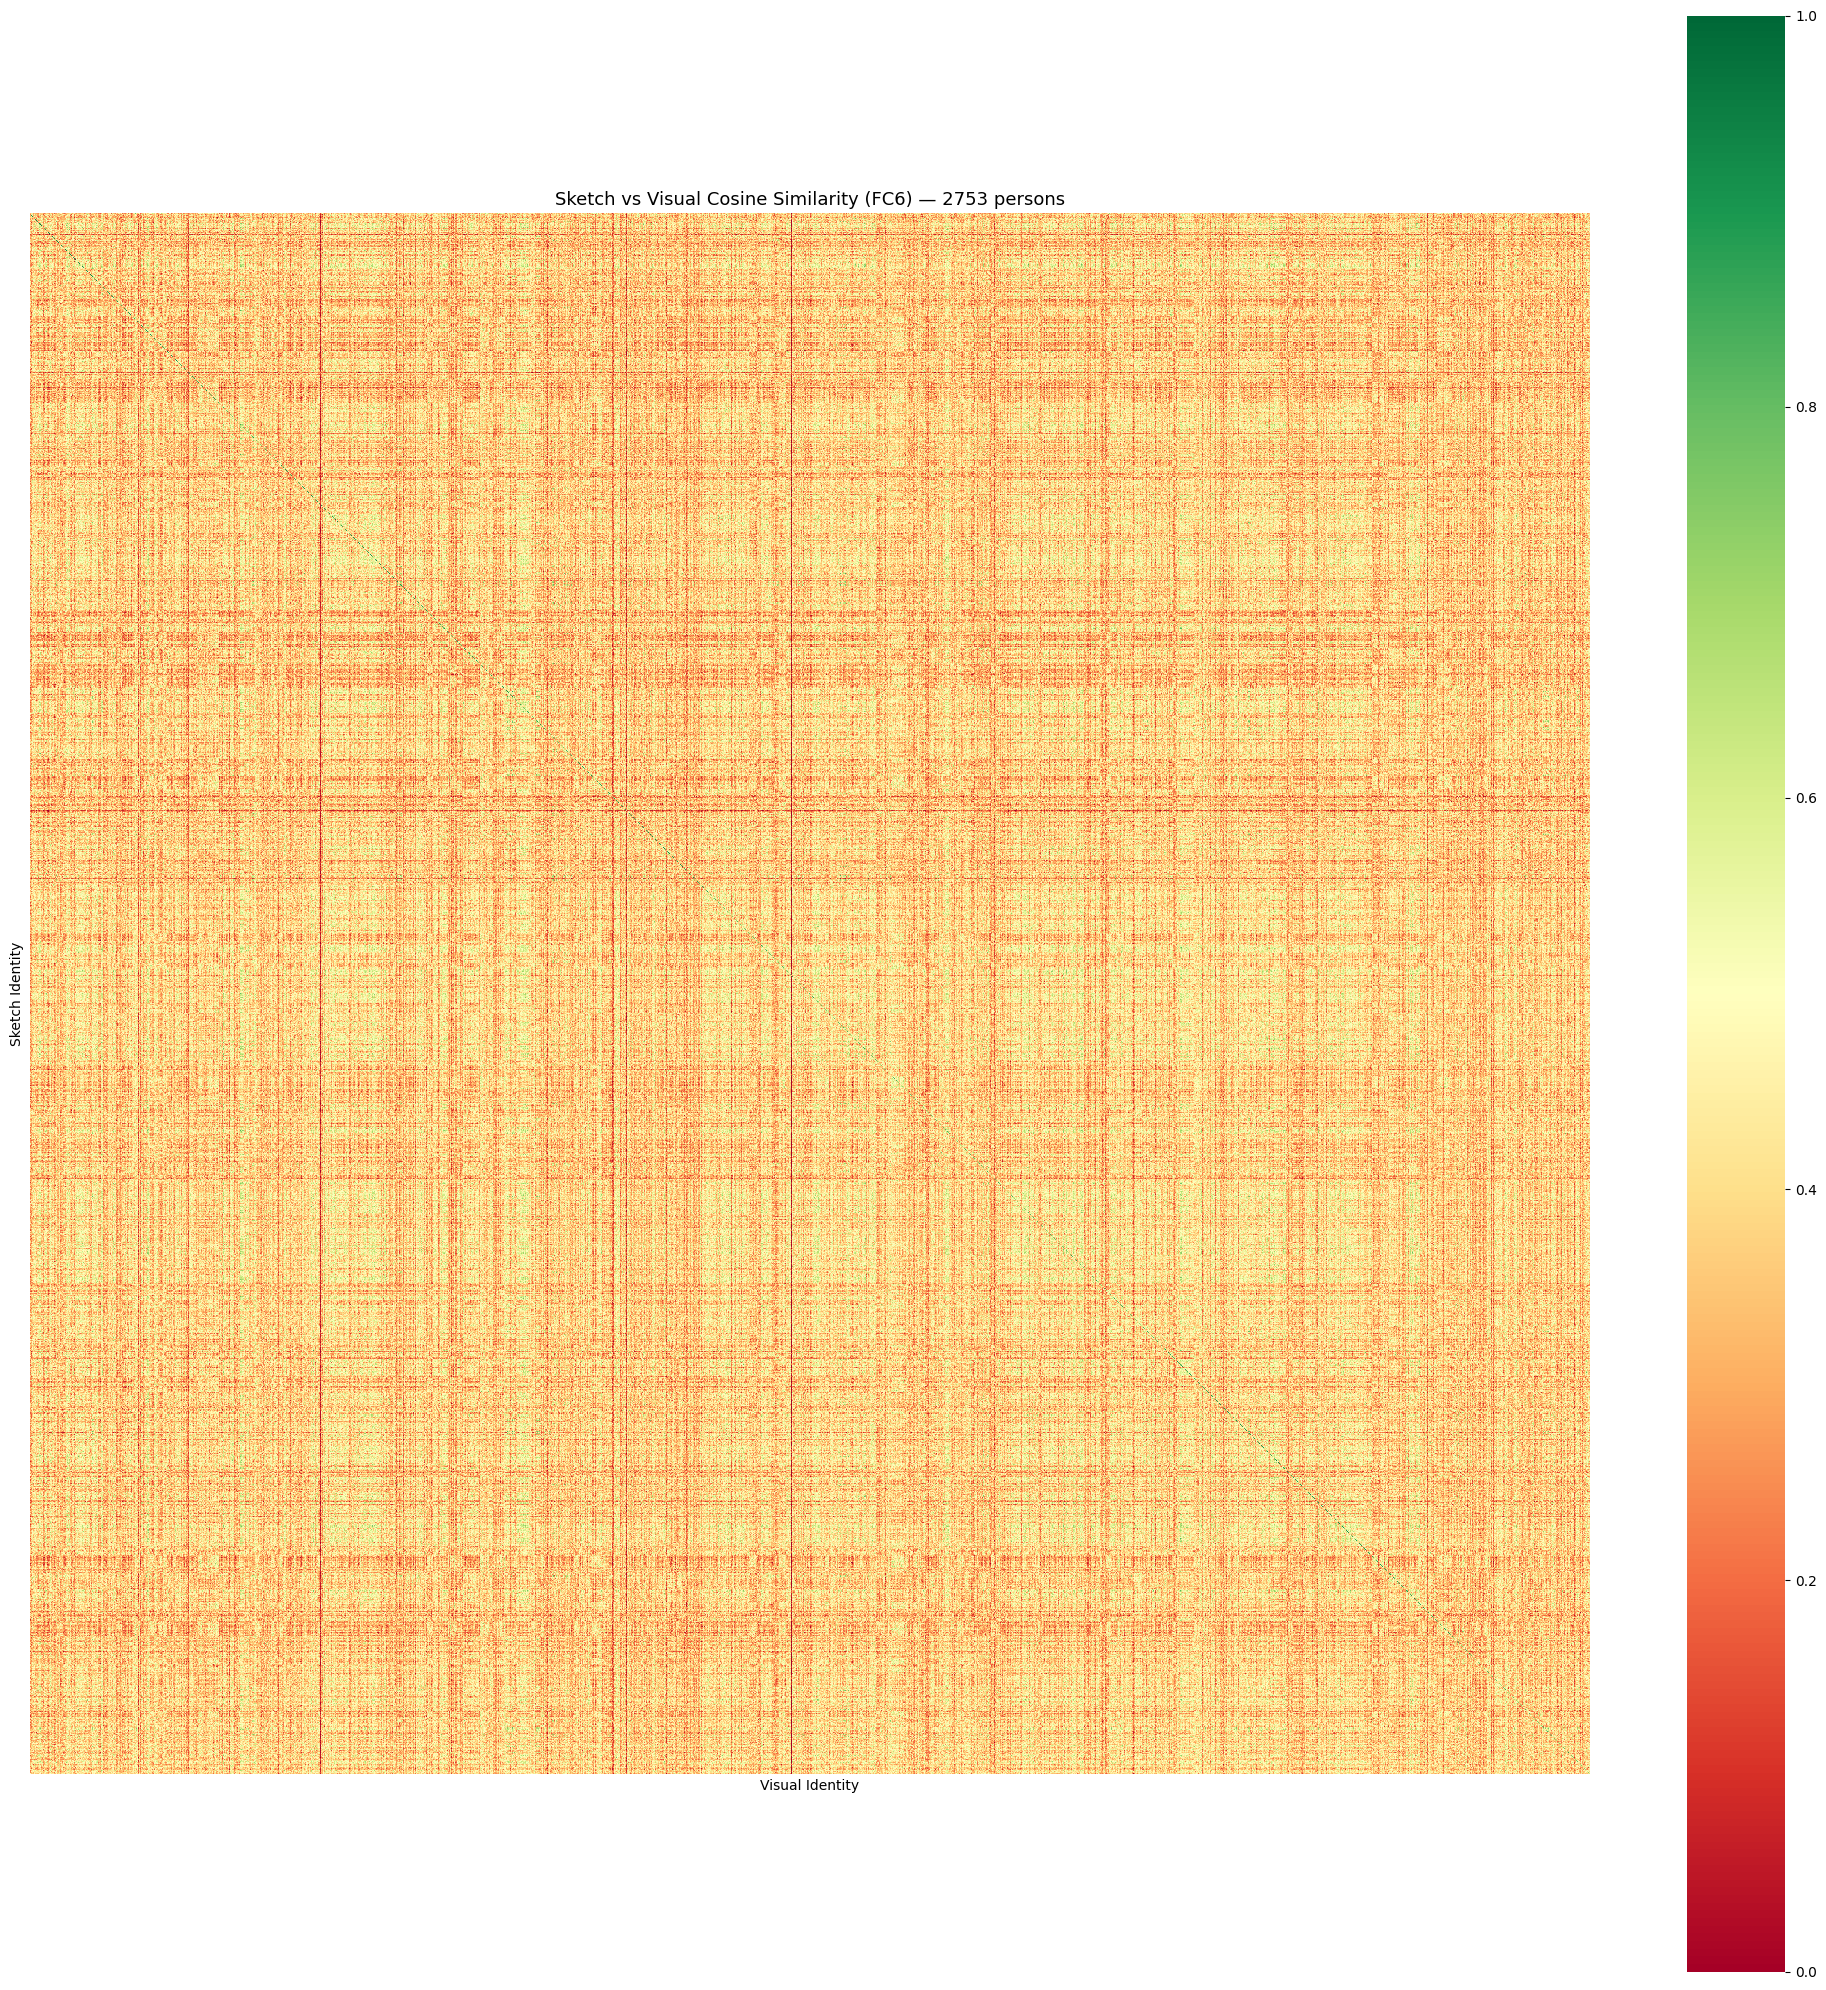

✅ Saved to ./features_tantring_with_mild_sharp/similarity_matrix_fc6.png


In [8]:
# Cell 8 — Plot similarity matrix (fixed size)
N = len(person_ids)

# Cap figure size to maximum 20x20 inches regardless of N
fig_size = min(20, max(8, N // 5))

plt.figure(figsize=(fig_size, fig_size))
sns.heatmap(
    sim_matrix,
    xticklabels=False,      # hide labels if too many persons
    yticklabels=False,
    cmap='RdYlGn',
    vmin=0, vmax=1,
    annot=False,            # never annotate — too many cells
    linewidths=0,           # no grid lines — too slow for large N
    square=True
)
plt.title(f'Sketch vs Visual Cosine Similarity ({LAYER.upper()}) — {N} persons', fontsize=13)
plt.xlabel('Visual Identity')
plt.ylabel('Sketch Identity')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'similarity_matrix_{LAYER}.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f'✅ Saved to {OUTPUT_DIR}/similarity_matrix_{LAYER}.png')

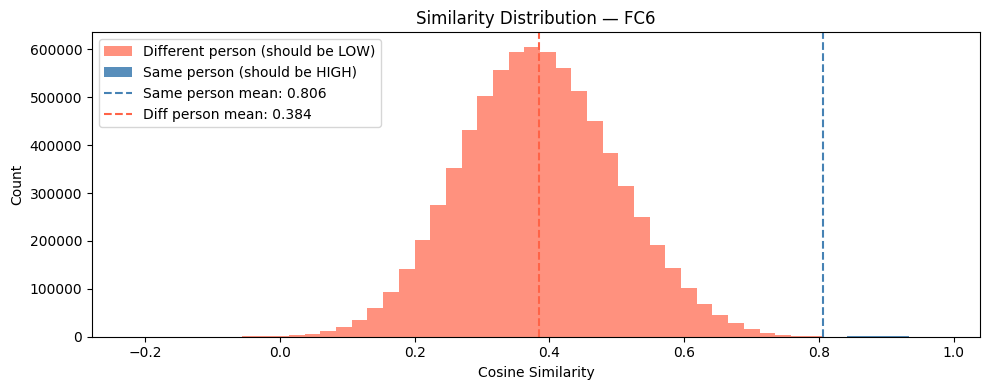

In [9]:
# Cell 9 — Diagonal vs Off-diagonal distribution plot
# Good model: two peaks clearly separated

diag     = np.diag(sim_matrix)
off_diag = sim_matrix[~np.eye(N, dtype=bool)]

plt.figure(figsize=(10, 4))
plt.hist(off_diag, bins=50, alpha=0.7, color='tomato',    label='Different person (should be LOW)')
plt.hist(diag,     bins=20, alpha=0.9, color='steelblue', label='Same person (should be HIGH)')
plt.axvline(diag.mean(),     color='steelblue', linestyle='--', linewidth=1.5, label=f'Same person mean: {diag.mean():.3f}')
plt.axvline(off_diag.mean(), color='tomato',    linestyle='--', linewidth=1.5, label=f'Diff person mean: {off_diag.mean():.3f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title(f'Similarity Distribution — {LAYER.upper()}')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'similarity_distribution_{LAYER}.png'), dpi=150)
plt.show()

In [10]:
# Cell 10 — Rank-1 Retrieval Accuracy
# For each sketch, find the most similar visual.
# If it matches the correct person → correct retrieval.

correct = 0
for i, person in enumerate(person_ids):
    best_match_idx = np.argmax(sim_matrix[i])
    if person_ids[best_match_idx] == person:
        correct += 1

accuracy = correct / len(person_ids) * 100
print(f'Rank-1 Retrieval Accuracy ({LAYER.upper()}): {correct}/{len(person_ids)} = {accuracy:.1f}%')
print()
print(f'Random-chance baseline for {len(person_ids)} persons: {100/len(person_ids):.1f}%')
print()
print('What this means:')
print('  100% → every sketch correctly matched to its own visual')
print(f'  {100/len(person_ids):.1f}%  → random chance (baseline to beat)')


Rank-1 Retrieval Accuracy (FC6): 2231/2753 = 81.0%

Random-chance baseline for 2753 persons: 0.0%

What this means:
  100% → every sketch correctly matched to its own visual
  0.0%  → random chance (baseline to beat)


In [11]:
# Cell 11 — Save everything
np.save(os.path.join(OUTPUT_DIR, f'sim_matrix_{LAYER}.npy'),  sim_matrix)
np.save(os.path.join(OUTPUT_DIR, 'person_ids.npy'), np.array(person_ids))

print(f'✅ Saved sim_matrix_{LAYER}.npy  →  shape {sim_matrix.shape}')
print(f'✅ Saved person_ids.npy          →  {len(person_ids)} persons')

✅ Saved sim_matrix_fc6.npy  →  shape (2753, 2753)
✅ Saved person_ids.npy          →  2753 persons


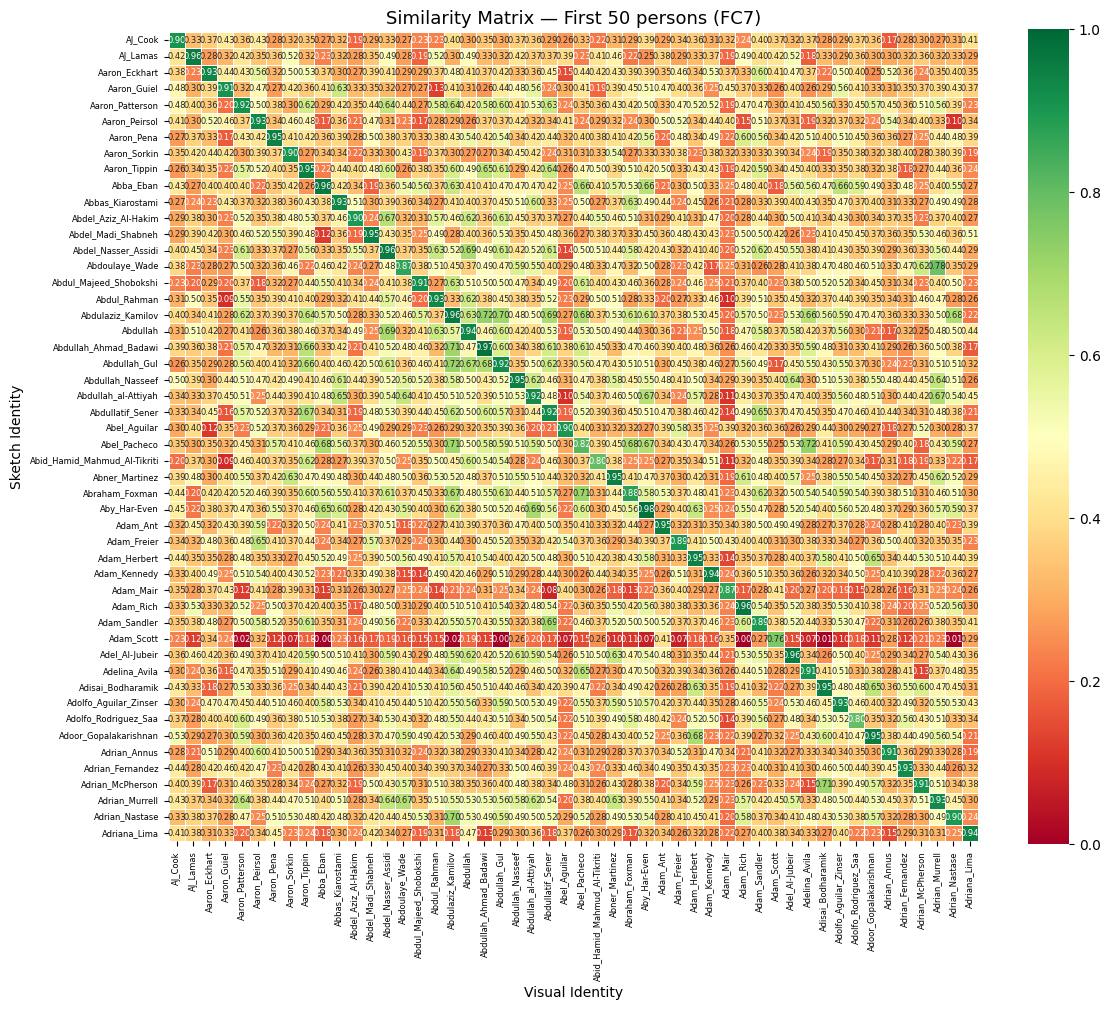

In [12]:
# Zoom into first 50 persons only — so diagonal is visible
N_SHOW = 50

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_matrix[:N_SHOW, :N_SHOW],
    xticklabels=person_ids[:N_SHOW],
    yticklabels=person_ids[:N_SHOW],
    cmap='RdYlGn',
    vmin=0, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    annot_kws={"size": 6}
)
plt.title(f'Similarity Matrix — First {N_SHOW} persons (FC7)', fontsize=13)
plt.xlabel('Visual Identity')
plt.ylabel('Sketch Identity')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [13]:
diag     = np.diag(sim_matrix)
mask     = ~np.eye(len(person_ids), dtype=bool)
off_diag = sim_matrix[mask]

print(f'Same person (diagonal)     mean: {diag.mean():.4f}')
print(f'Different person (off-diag) mean: {off_diag.mean():.4f}')
print(f'Separation gap: {diag.mean() - off_diag.mean():.4f}')
print()
print('Good result  → gap > 0.3')
print('Okay result  → gap 0.1–0.3')  
print('Weak result  → gap < 0.1  ← likely what you have now')

Same person (diagonal)     mean: 0.8060
Different person (off-diag) mean: 0.3843
Separation gap: 0.4217

Good result  → gap > 0.3
Okay result  → gap 0.1–0.3
Weak result  → gap < 0.1  ← likely what you have now


---
## How to read the similarity matrix
```
         Visual_A  Visual_B  Visual_C
Sketch_A  [ 0.92     0.21      0.18 ]   ← A matched correctly ✅
Sketch_B  [ 0.19     0.88      0.22 ]   ← B matched correctly ✅
Sketch_C  [ 0.20     0.31      0.85 ]   ← C matched correctly ✅
```
- **Bright diagonal** = model working well
- **Dark off-diagonal** = model correctly separating identities
- **Rank-1 accuracy** = % of sketches that found correct visual as top match

## Change layer
Change `LAYER = 'fc6'` in Cell 2 and re-run to compare FC6 vs FC7.